# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [67]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options.sampler_options import SamplerOptions

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [68]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as QCrankV2, analyze_qcrank_residuals

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Current working directory: c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\exploration_notebooks


In [69]:
sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x000002084AE7F850>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [70]:
def run_sim_job(qc, n_shots = 2**8, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param qc: QuantumCircuit to run
    :param n_shots: Number of shots to run the circuit for
    :param verbose: If True, print the circuit and counts

    :return: Counts of the measurement outcomes
    """

    transpiled_circuit = transpile(qc, sim)    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    if verbose:
        print("Circuit before transpilation")
        display(qc.draw('mpl'))
        print("Circuit after transpilation")
        display(transpiled_circuit.draw('mpl', style="iqp"))

        print("Counts:")
        print(counts)
        display(plot_distribution(counts))

    return counts

In [71]:
def display_statevector(qc):
    """
    Display the statevector, unitary matrix, and Bloch sphere representation of a quantum circuit.

    :param qc: QuantumCircuit to analyze

    :return: Statevector of the quantum circuit
    """
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [72]:
def plot_residuals(actual, theory, title, x_label, y_label, legend):
    min_val = min(min(actual), min(theory))
    max_val = max(max(actual), max(theory))

    plt.scatter(theory, actual, label=legend)
    # calculate slope of line of best fit
    coefficients = np.polyfit(theory, actual, 1)
    print(f"Slope of line of best fit: {coefficients[0]:.4f}")
    # plot line of best fit
    plt.plot(theory, np.poly1d(coefficients)(theory), color='red', label='Line of Best Fit')    

    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.grid(True)

    plt.show()

In [73]:
def ehands_addition(qc, q_a, q_b, weight, negation=False, verbose=False, barrier=False):
    """ 
    Perform an EHands addition of two qubits with a given weight and optional negation.

    :param qc: QuantumCircuit to which the addition will be applied
    :param q_a: Index of the first qubit
    :param q_b: Index of the second qubit
    :param weight: Weight for the addition (between 0 and 1)
    :param negation: If True, negate the second qubit before addition

    :return: QuantumCircuit with the eHANDS addition applied   
    """
    alpha = np.arccos(1 - 2 * weight)

    qc_add = QuantumCircuit(2)

    if negation:
        qc_add.x(1)

    qc_add.rz(pi/2, 1)
    qc_add.cx(0, 1)
    qc_add.ry(alpha/2, 0)
    qc_add.cx(1, 0) 
    qc_add.ry(-alpha/2, 0)


    if verbose:
        print("Addition Circuit:")
        display(qc_add.draw('mpl'))
    
    return qc.compose(qc_add, qubits=[q_a, q_b])


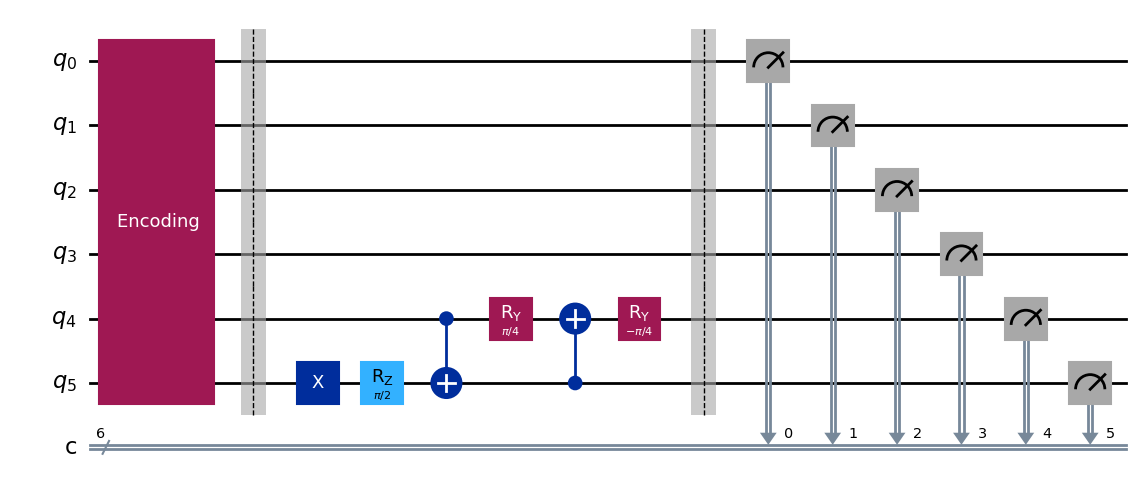

In [ ]:
# Paper figure: circuit isolating EHANDS addition (negation=True) after an abstract encoding.
# Six qubits q0..q5; Encoding is a single box spanning all six wires.
# Replace the Encoding subcircuit with your real encoder when exporting the final figure.

PAPER_ADD_WEIGHT = 0.5  # EHANDS weight w in [0, 1]

encoding_sub = QuantumCircuit(6)
for q in range(6):
    encoding_sub.id(q)  # placeholders so the subcircuit converts to a Gate (barriers are not allowed inside to_gate)
encoding_gate = encoding_sub.to_gate(label="Encoding  ")

qc_paper_addition = QuantumCircuit(6, 6)
qc_paper_addition.append(encoding_gate, [0, 1, 2, 3, 4, 5])

qc_paper_addition.barrier()

qc_paper_addition = ehands_addition(
    qc_paper_addition,
    q_a=4,
    q_b=5,
    weight=PAPER_ADD_WEIGHT,
    negation=True,
    barrier=True,
)

qc_paper_addition.barrier()
qc_paper_addition.measure(range(5), range(5))


def hide_multigate_wire_indices(fig):
    """Remove Qiskit MPL's default 0..n-1 labels on the left inside multi-qubit gate boxes."""
    for ax in fig.axes:
        for txt in list(ax.texts):
            if txt.get_ha() != "left" or txt.get_va() != "center":
                continue
            s = txt.get_text().strip()
            if s.isdigit():
                txt.remove()
    return fig


fig = qc_paper_addition.draw(
    "mpl",
    fold=-1,
    plot_barriers=True,
    style={"showindex": False},
)
hide_multigate_wire_indices(fig)
display(fig)

fig.savefig("isolated-ehands.png", bbox_inches="tight")

## Subtraction Setup with QCrank

In [75]:
def configure_qcrank_options(n_shots):
    options = SamplerOptions()
    options.default_shots=n_shots
    return options

In [76]:
def run_sim_job_qcrank(encoding_args, n_cubes, n_shots = 2**12, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param encoding_args: dictionary including information about the QC of encoded data
    :param n_cubes: number of cubes being processed
    :param n_shots: number of shots to run
    :param verbose: print out extra details and draw circuit

    :return: Counts of the measurement outcomes
    """
    options = configure_qcrank_options(n_shots)
    sampler = Sampler(mode=sim, options=options)

    job = sampler.run(tuple(encoding_args['qcEL']))
    jobRes = job.result()

    #countsL = [jobRes[i].data.meas.get_counts() for i in range(n_cubes)]
    countsL = [jobRes[i].data.c.get_counts() for i in range(n_cubes)]

    if verbose:
        qc = encoding_args['qc']
        cxDepth=qc.depth(filter_function=lambda x: x.operation.name == 'cx')
        print(f'.... PARAMETRIZED CIRCUIT .............. n_cubes={n_cubes}, cx-depth={cxDepth}')
        print('Gates count:', qc.count_ops())
        display(qc.draw('mpl'))


    return countsL

## Notes 03/09/26

look into plotting statistical error for binomial distr, make a plot like Chris' (y=actual vs x=expected)

give plot titles

just use a few pre-selected weights, don't need to find the optimal weight

when doing the actual subtraction, try 2 different methods:

- method 1: encode isovalue into array of same length as data, then do elementwise subtraction

- method 2: encode Data array using QCrank, encode Isovalue using single Ry gate, subtract data qubit by iso qubit

- method 3: encode isovalue into the weight of the EHands addition, then do subtraction that way (ask Dr. Bethel for more details)

    - let d[i] = data[i]
    - let t = isolevel
    - step 1: compute NEG(t)
    - step 2: compute weight sum of d[i] + NEG(t) using w = 0.5
    - step 3: multiply step 2 by 2.0

when running tests, the standard number of shots is 4k per data point 

there is some bug possibly in the calculation of EV in get_EV()

how long does circuit get for data size N? (compound metric (1 and multi qubit gates))

## Method 1
### Encode Data array using QCrank, encode Isovalue using single Ry gate

In [77]:
def initialize_n_data(n_cubes, n_arr, data_range, make_iso_array=False, isovalue=0.5):
    n_data = n_cubes * (2**3)
    nq_addr = math.ceil(math.log2(n_data))
    nq_data = n_arr

    if make_iso_array:
        n_arr -= 1

    data_inp = [np.random.uniform(data_range[0], data_range[1], (n_data, n_cubes)) for _ in range(n_arr)]

    if make_iso_array:
        data_inp.append(np.full((n_data, n_cubes), isovalue))

    return {
        'n_cubes': n_cubes,
        'n_data': n_data,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'num_q': nq_addr + nq_data,
        'addr_qL': range(nq_addr),
        'data_qL': range(nq_addr, nq_addr + nq_data),
        'data_inp': data_inp
    }

In [78]:
def encode_with_qcrank_2(data_args, useCZ=False, measure=True, barrier=True):
    nq_addr = data_args['nq_addr']
    nq_data = data_args['nq_data']

    qcrankObj = QCrankV2(nq_addr, nq_data, useCZ=useCZ, measure=measure, barrier=barrier)

    qc = qcrankObj.circuit

    if len(data_args['data_inp']) > 1:
        combined_arrays = np.stack([data_args['data_inp'][0], data_args['data_inp'][1]], axis=1)
        qcrankObj.bind_data(combined_arrays)
    
    else:
        qcrankObj.bind_data(data_args['data_inp'][0])

    qcEL = qcrankObj.instantiate_circuits()
    return {
        'qc': qc,
        'qcEL': qcEL,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'qcrankObj': qcrankObj
    }

In [79]:
def analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=False):
    # Iterate over all input arrays
    for i in range(data_args['nq_data']):
        # Save data and recovered to lists
        all_data_list[i].append(data_args['data_inp'][i])
        all_rec_list[i].append(recoveredL[i])

        # QCrank analysis
        print(f"Analyzing residuals for array {i}")
        analyze_qcrank_residuals(data_args['data_inp'][i], recoveredL[i])
        
        if verbose:
            for j in range(data_args['n_cubes']):
                print(f'\nCube {j} original data:\n', data_args['data_inp'][i][..., j].T)
                print(f'Reconstructed data:\n', recoveredL[i][..., j].T)
                print(f'Difference:\n', (data_args['data_inp'][i][..., j] - recoveredL[i][..., j]).T)
                if i > 2: 
                    break

In [80]:
def test_encode_decode_2_data():
    n_arr = 2
    isovalue = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=True, isovalue=isovalue)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args)

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        

    title = 'Original Data vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                   np.concatenate(all_data_list[0]).flatten(), 
                   title, x_label, y_label, legend)

    title = 'Original Isovalue Array vs Reconstructed Array'
    x_label = 'Original Isovalue'
    y_label = 'Reconstructed Isovalue'
    legend = 'Data Points'
    plt.hist(np.concatenate(all_rec_list[1]).flatten(), bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=8
Gates count: OrderedDict({'ry': 16, 'cx': 16, 'measure': 5, 'h': 3, 'barrier': 2})


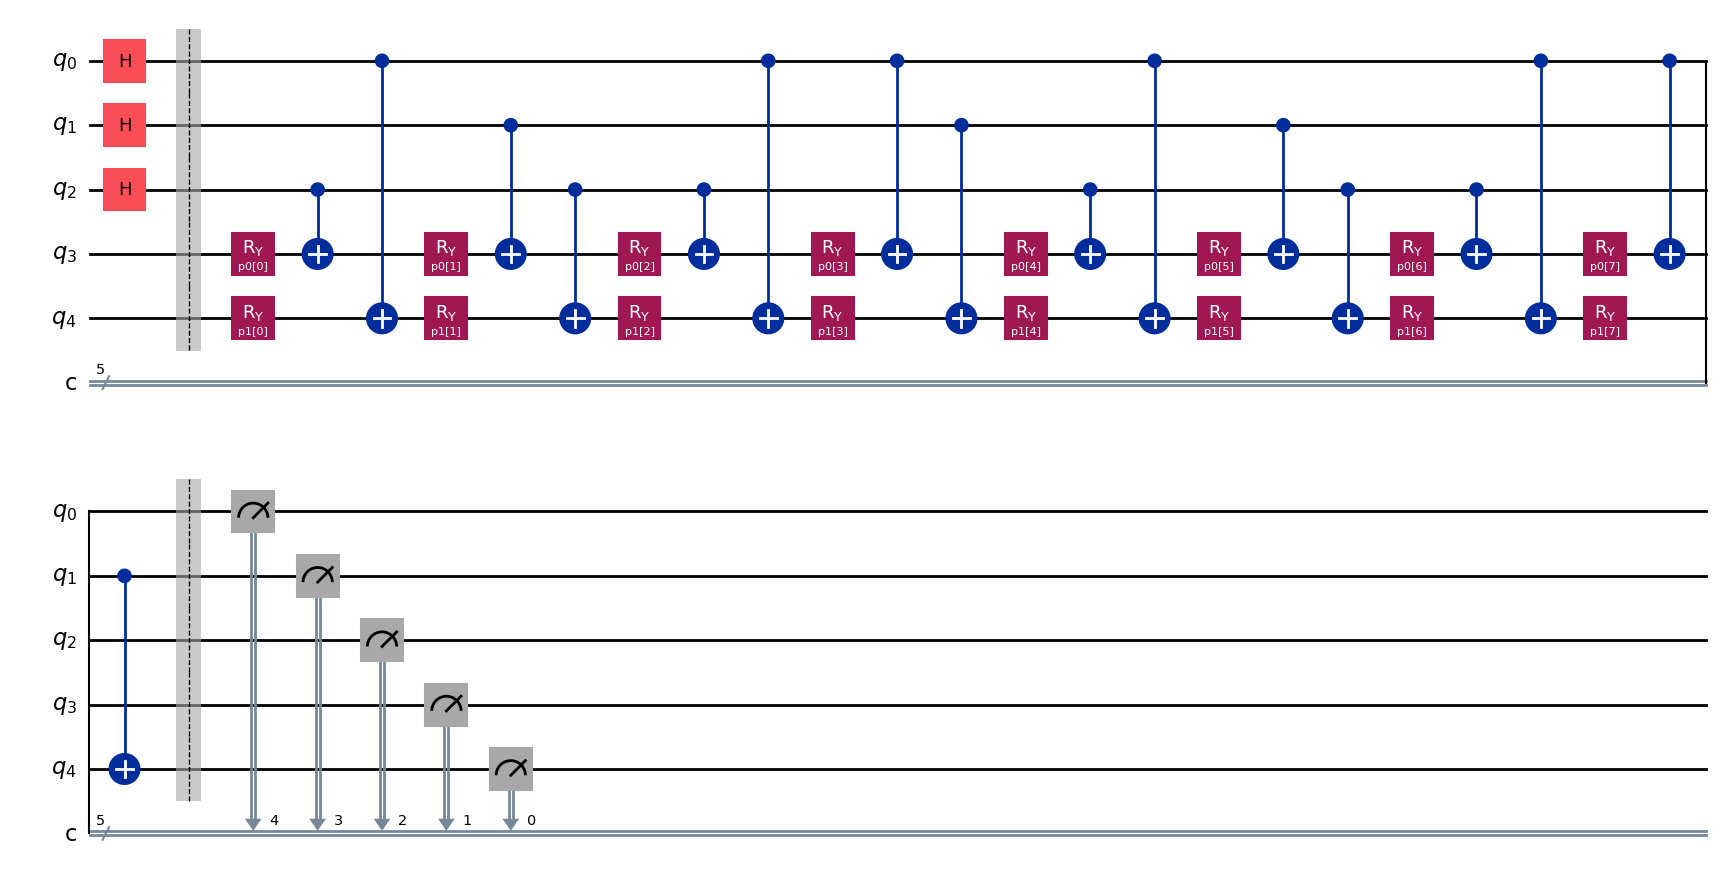

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean= 0.002  std= 0.011  corr=1.00   tilt angle=1.0/deg
Overall 
residuals: mean=0.002  std=0.011  corr=1.000


Cube 0 original data:
 [-0.86078003  0.64811921  0.21984991  0.26894875  0.15718478  0.47448834
 -0.78288111 -0.80424227]
Reconstructed data:
 [-0.86781327  0.65578922  0.20880716  0.26869671  0.17725587  0.46679832
 -0.77939042 -0.82164671]
Difference:
 [ 0.00703323 -0.00767001  0.01104275  0.00025204 -0.02007109  0.00769002
 -0.00349069  0.01740444]
Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean=-0.001  std= 0.010  corr=nan   tilt angle=nan/deg
Overall 
residuals: mean=-0.001  std=0.010  corr=nan


Cube 0 original data:
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Reconstructed data:
 [0.51547912 0.51124003 0.49721752 0.49963459 0.51149567 0.49000247
 0.4934688  0.48644026]
Difference:
 [

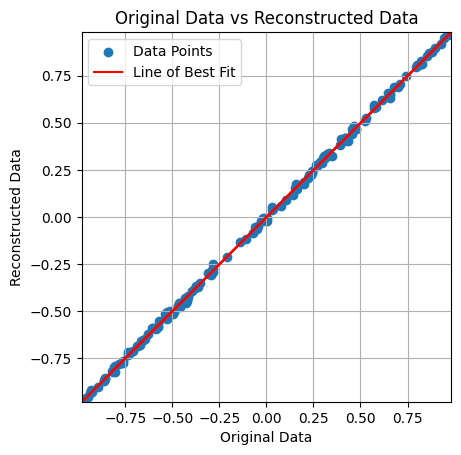

C:\Users\waffles\AppData\Local\Temp\ipykernel_10532\2560197121.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


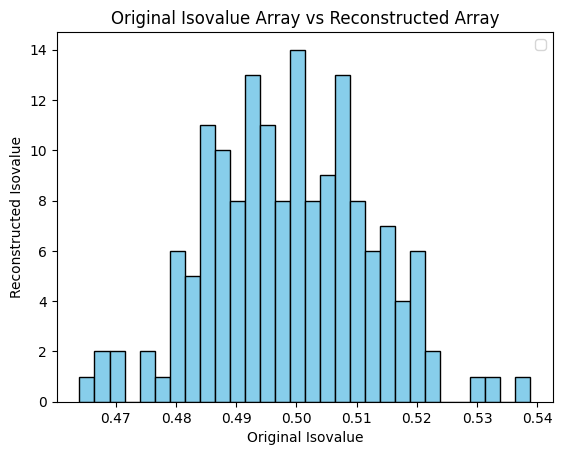

In [81]:
test_encode_decode_2_data()

In [82]:
def test_encode_decode_2_data_manual_measure():
    n_arr = 2
    isovalue = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=True, isovalue=isovalue)

        qc_main = QuantumCircuit(data_args['num_q'], data_args['num_q'])

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        # Add measurement
        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        

    title = 'Original Data vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                   np.concatenate(all_data_list[0]).flatten(), 
                   title, x_label, y_label, legend)

    title = 'Original Isovalue Array vs Reconstructed Array'
    x_label = 'Original Isovalue'
    y_label = 'Reconstructed Isovalue'
    legend = 'Data Points'
    plt.hist(np.concatenate(all_rec_list[1]).flatten(), bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=8
Gates count: OrderedDict({'ry': 16, 'cx': 16, 'measure': 5, 'h': 3, 'barrier': 2})


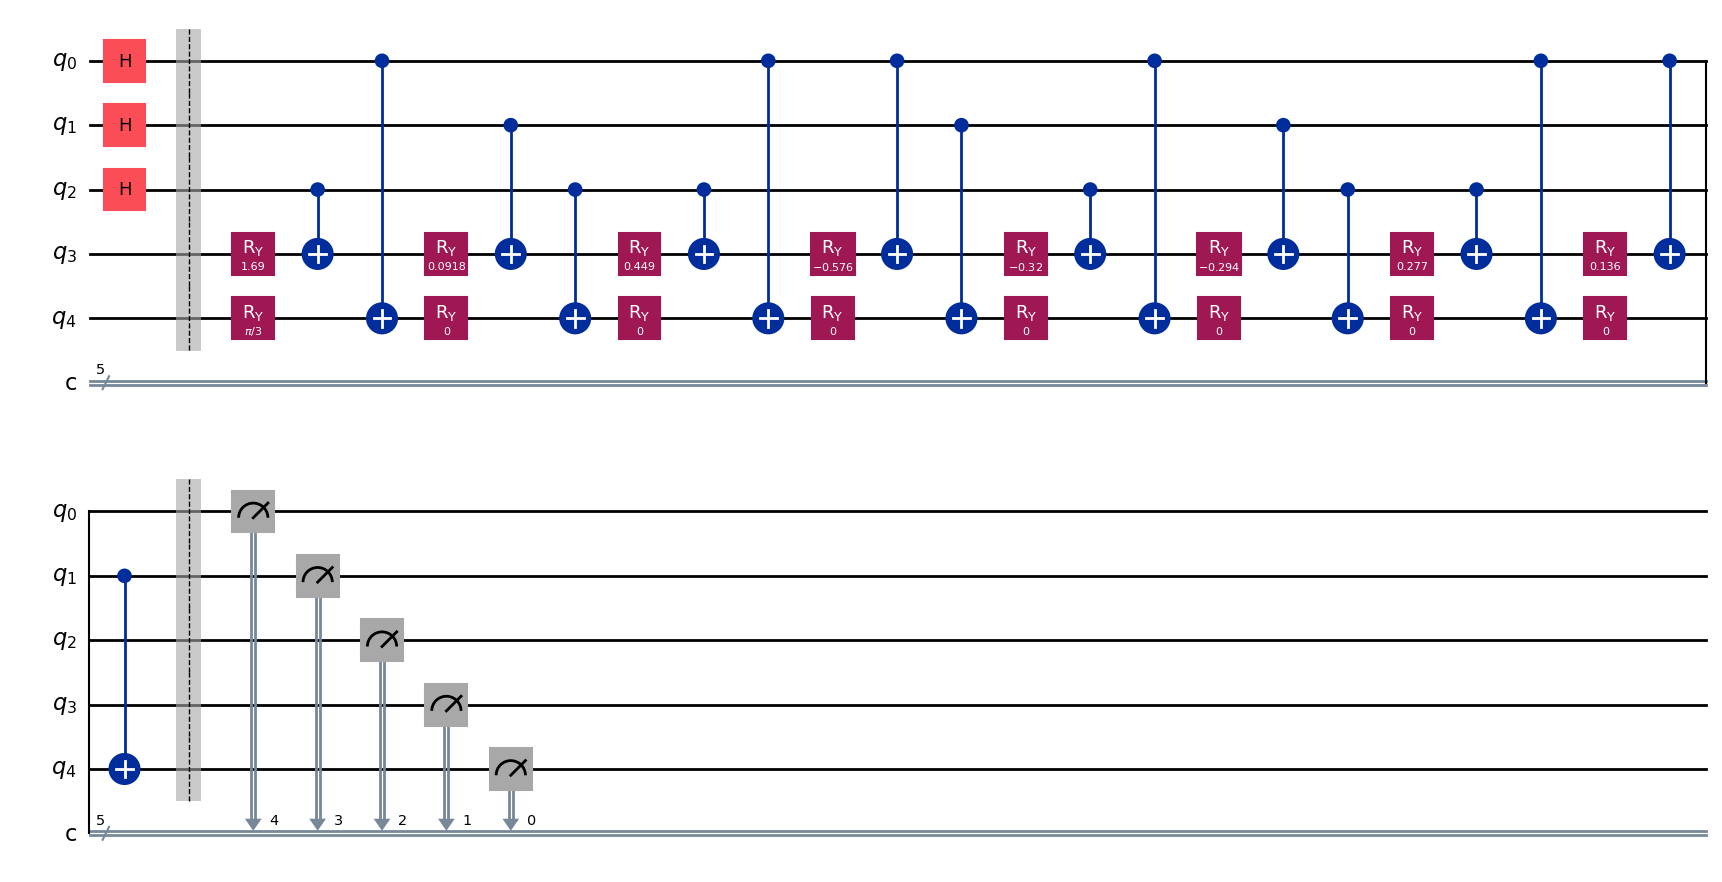

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean= 0.001  std= 0.012  corr=1.00   tilt angle=0.9/deg
Overall 
residuals: mean=0.001  std=0.012  corr=1.000


Cube 0 original data:
 [ 0.11692811  0.91891611 -0.97906812 -0.80641528 -0.28239339  0.73768224
  0.63561512 -0.92022487]
Reconstructed data:
 [ 0.11800339  0.92105908 -0.97715156 -0.80082584 -0.29594392  0.71231187
  0.64108509 -0.90303907]
Difference:
 [-0.00107529 -0.00214297 -0.00191655 -0.00558944  0.01355052  0.02537038
 -0.00546998 -0.0171858 ]
Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean= 0.006  std= 0.008  corr=nan   tilt angle=nan/deg
Overall 
residuals: mean=0.006  std=0.008  corr=nan


Cube 0 original data:
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Reconstructed data:
 [0.49309426 0.48173572 0.49378015 0.48894826 0.49674512 0.50456452
 0.50799907 0.48625181]
Difference:
 [ 

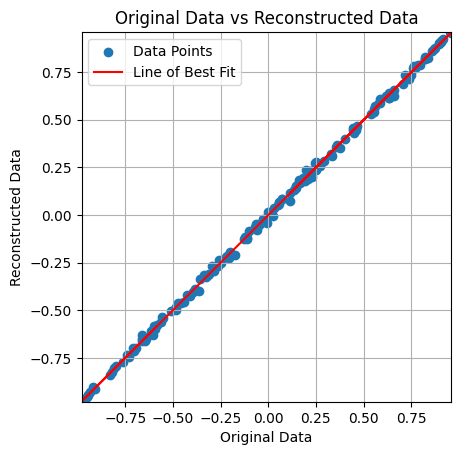

C:\Users\waffles\AppData\Local\Temp\ipykernel_10532\2313898271.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


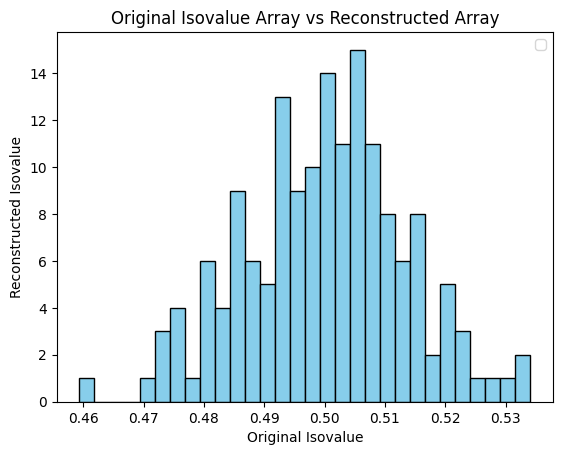

In [83]:
test_encode_decode_2_data_manual_measure()

In [84]:
def test_qcrank_ehands():
    n_arr = 2
    isovalue = 0.5
    weight = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=True, isovalue=isovalue)

        qc_main = QuantumCircuit(data_args['num_q'], data_args['num_q'])

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        # Add EHands Addition
        q_a = data_args['data_qL'][0]
        q_b = data_args['data_qL'][1]

        qc_main = ehands_addition(qc_main, q_a, q_b, weight=weight, verbose=verbose, barrier=True)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

Addition Circuit:


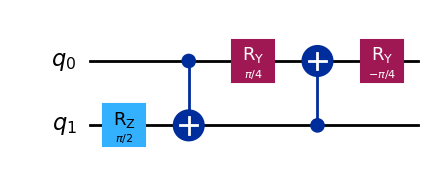

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=10
Gates count: OrderedDict({'ry': 18, 'cx': 18, 'measure': 5, 'h': 3, 'barrier': 2, 'rz': 1})


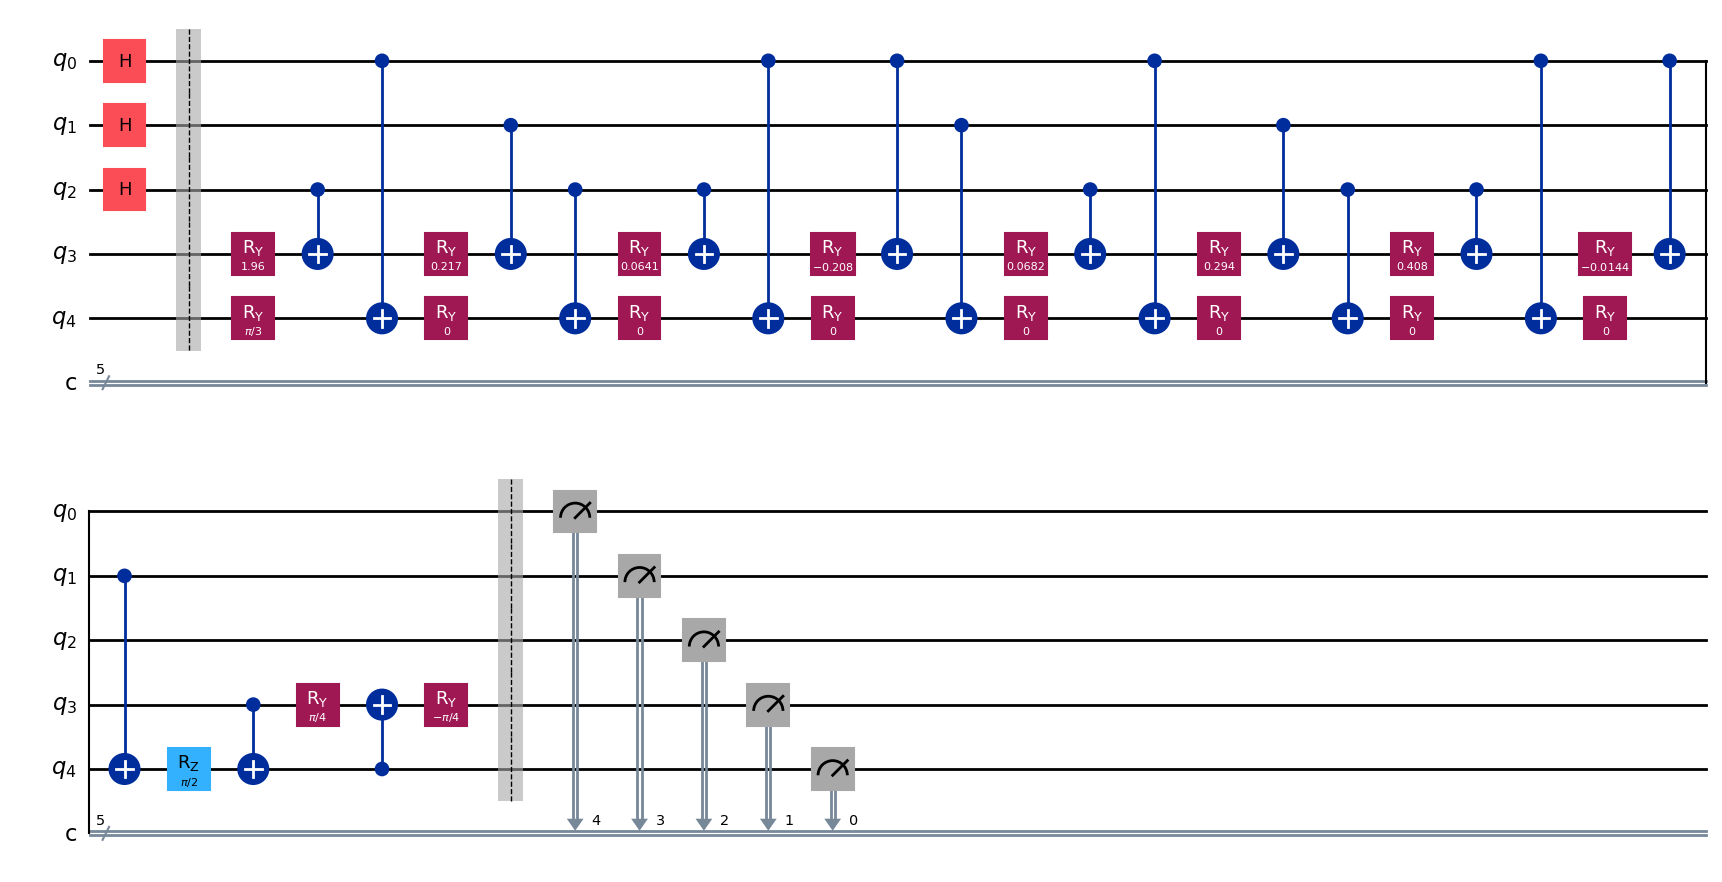

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.423  std= 0.250  corr=1.00   tilt angle=2.6/deg
Overall 
residuals: mean=-0.423  std=0.250  corr=0.999


Cube 0 original data:
 [-0.93909404  0.67872023 -0.70550355 -0.24793891  0.28764    -0.52323435
 -0.66025205 -0.59936847]
Reconstructed data:
 [-0.21630094  0.61041562 -0.13377679  0.12299209  0.41133544 -0.00440098
 -0.07339673 -0.04371184]
Difference:
 [-0.7227931   0.06830461 -0.57172675 -0.37093099 -0.12369544 -0.51883338
 -0.58685532 -0.55565662]
Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean= 0.670  std= 0.261  corr=nan   tilt angle=nan/deg
Overall 
residuals: mean=0.670  std=0.261  corr=nan


Cube 0 original data:
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Reconstructed data:
 [-0.45454545  0.34702053 -0.36733186 -0.09805802  0.13500365 -0.26601467
 -0.35284077 -0.30598291]
Differ

In [85]:
all_rec_list, all_data_list = test_qcrank_ehands()

In [86]:
def display_results(all_data_list, all_rec_list):
    print("-----------------------------Analysis of Original vs Reconstructed----------------------------------")
    avg_dif = 0
    print("+----------------+----------------+----------------+")
    print("| Original Data  | Reconstructed  | Difference     |")
    print("+----------------+----------------+----------------+")

    for o, r in zip(np.concatenate(all_data_list[0]).flatten(),
                    np.concatenate(all_rec_list[0]).flatten()):
        dif = o - r
        avg_dif += dif
        print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

    print("+----------------+----------------+----------------+")

    n_points = len(np.concatenate(all_data_list[0]).flatten())
    avg_dif /= n_points

    print(f"Average Difference: {avg_dif}")


    title = 'Original Data vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                    np.concatenate(all_data_list[0]).flatten(), 
                    title, x_label, y_label, legend)

    print("-----------------------------Analysis of Isovalue vs Reconstructed----------------------------------")
    avg_dif = 0
    print("+----------------+----------------+----------------+")
    print("| Original Iso   | Reconstructed  | Difference     |")
    print("+----------------+----------------+----------------+")

    for o, r in zip(np.concatenate(all_data_list[1]).flatten(),
                    np.concatenate(all_rec_list[1]).flatten()):
        dif = o - r
        avg_dif += dif
        print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

    print("+----------------+----------------+----------------+")

    n_points = len(np.concatenate(all_data_list[0]).flatten())
    avg_dif /= n_points

    print(f"Average Difference: {avg_dif}")


    title = 'Original Isovalue Array vs Reconstructed Array'
    x_label = 'Original Isovalue'
    y_label = 'Reconstructed Isovalue'
    legend = 'Data Points'
    plt.hist(np.concatenate(all_rec_list[1]).flatten(), bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.939094      | -0.216301      | -0.722793      |
| 0.678720       | 0.610416       | 0.068305       |
| -0.705504      | -0.133777      | -0.571727      |
| -0.247939      | 0.122992       | -0.370931      |
| 0.287640       | 0.411335       | -0.123695      |
| -0.523234      | -0.004401      | -0.518833      |
| -0.660252      | -0.073397      | -0.586855      |
| -0.599368      | -0.043712      | -0.555657      |
| -0.920515      | -0.195595      | -0.724920      |
| -0.245524      | 0.140034       | -0.385558      |
| -0.412093      | 0.068466       | -0.480559      |
| 0.469620       | 0.493101       | -0.023481      |
| 0.807273       | 0.666170       | 0.141103       |
| -0.085325      | 0.224219       | -0.309543      

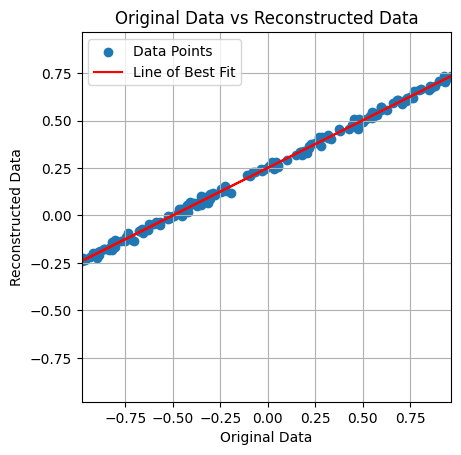

-----------------------------Analysis of Isovalue vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Iso   | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| 0.500000       | -0.454545      | 0.954545       |
| 0.500000       | 0.347021       | 0.152979       |
| 0.500000       | -0.367332      | 0.867332       |
| 0.500000       | -0.098058      | 0.598058       |
| 0.500000       | 0.135004       | 0.364996       |
| 0.500000       | -0.266015      | 0.766015       |
| 0.500000       | -0.352841      | 0.852841       |
| 0.500000       | -0.305983      | 0.805983       |
| 0.500000       | -0.477616      | 0.977616       |
| 0.500000       | -0.130393      | 0.630393       |
| 0.500000       | -0.217669      | 0.717669       |
| 0.500000       | 0.241346       | 0.258654       |
| 0.500000       | 0.402385       | 0.097615       |
| 0.500000       | -0.021905      | 0.521905       

C:\Users\waffles\AppData\Local\Temp\ipykernel_10532\1204628690.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


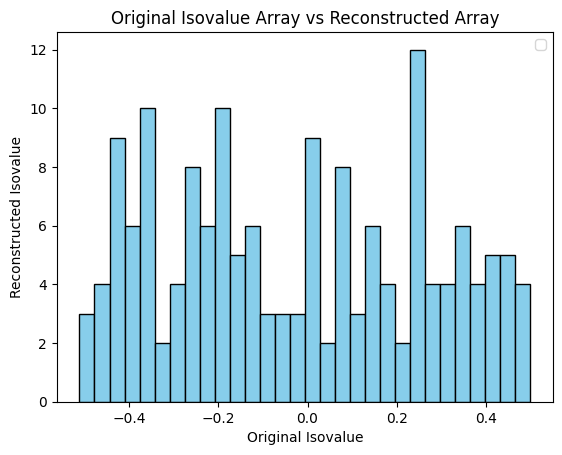

In [87]:
display_results(all_data_list, all_rec_list)

## Method 2
### Encode Data array using QCrank, encode Isovalue using single Ry gate

In [88]:
def test_qcrank_ehands_single_iso():
    n_arr = 1
    isovalue = 0.5
    weight = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=False)

        qc_main = QuantumCircuit(data_args['num_q'] + 1, data_args['num_q'] + 1)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        # add iso value qubit 
        qc_iso = QuantumCircuit(1, 1)
        qc_iso.ry(np.arccos(isovalue), 0)

        qc_main.compose(qc_iso, data_args['num_q'], inplace=True)

        # Add EHands Addition
        q_a = data_args['data_qL'][0]
        q_b = q_a + 1

        print(f"q_a: {q_a}, q_b: {q_b}")

        qc_main = ehands_addition(qc_main, q_a, q_b, weight=weight, verbose=verbose, barrier=True)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

q_a: 3, q_b: 4
Addition Circuit:


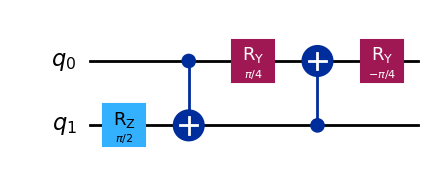

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=10
Gates count: OrderedDict({'ry': 11, 'cx': 10, 'measure': 4, 'h': 3, 'barrier': 2, 'rz': 1})


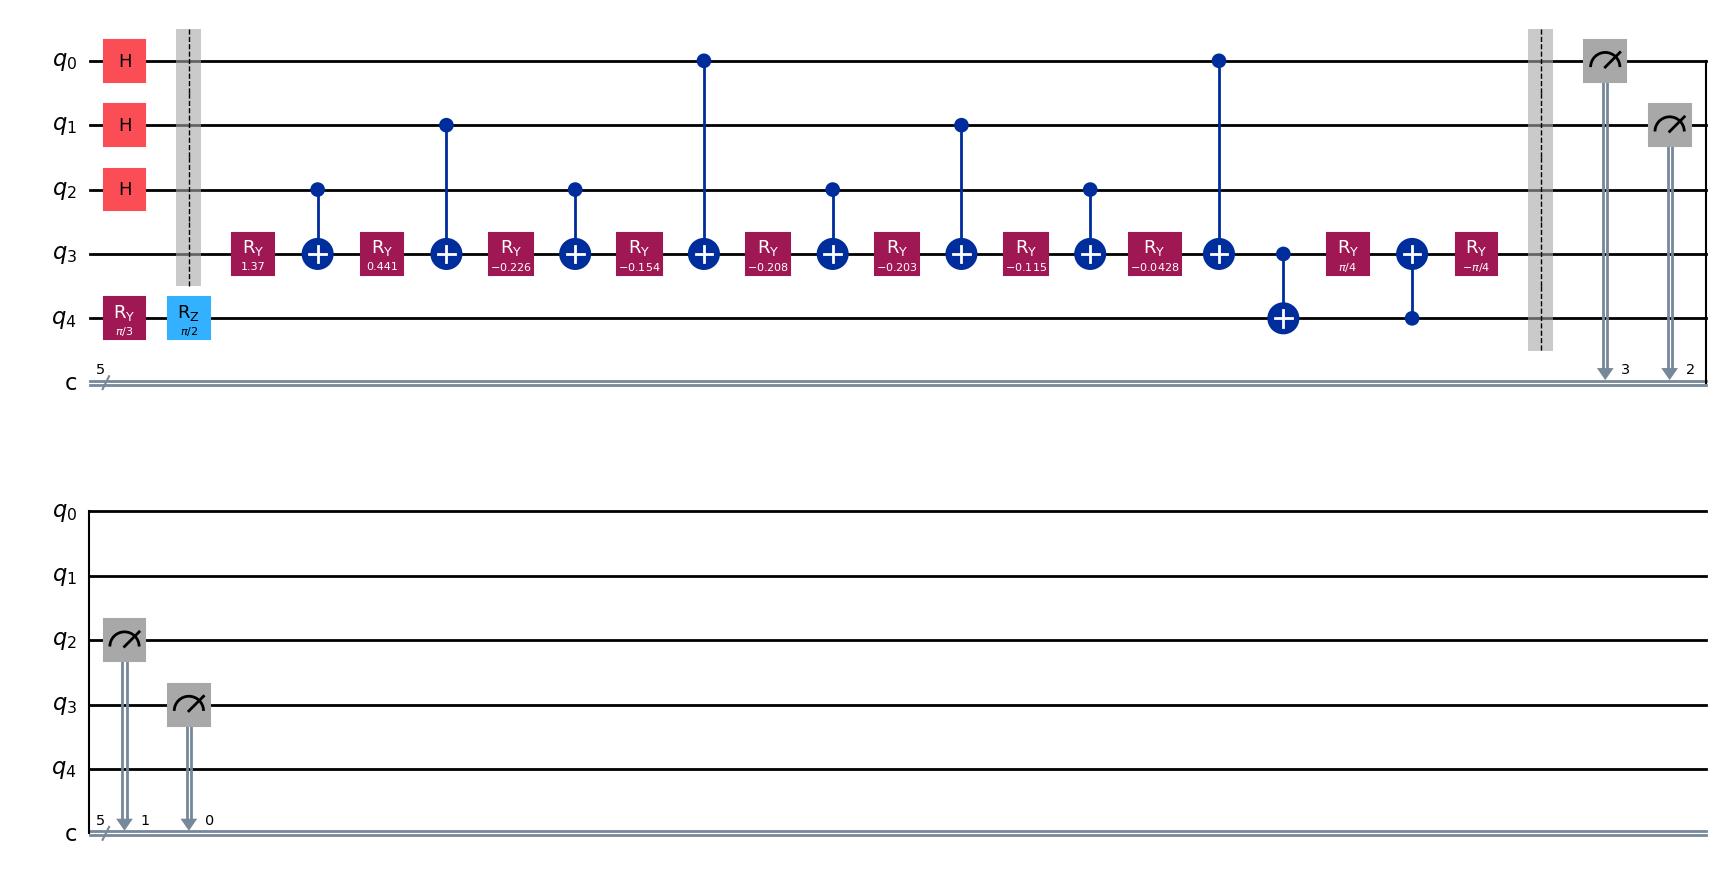

QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.152  std= 0.273  corr=1.00   tilt angle=1.4/deg
Overall 
residuals: mean=-0.152  std=0.273  corr=1.000


Cube 0 original data:
 [ 0.65017527  0.47966149 -0.76801973  0.59366992 -0.41744178  0.59332098
 -0.35966649  0.70979636]
Reconstructed data:
 [ 0.58        0.49547739 -0.15459883  0.53783133  0.03854545  0.53609756
  0.05435847  0.6058923 ]
Difference:
 [ 0.07017527 -0.01581589 -0.6134209   0.05583859 -0.45598723  0.05722342
 -0.41402496  0.10390406]
q_a: 3, q_b: 4
QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.142  std= 0.237  corr=1.00   tilt angle=2.6/deg
Overall 
residuals: mean=-0.142  std=0.237  corr=0.999

q_a: 3, q_b: 4
QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Sh

In [89]:
all_rec_list, all_data_list = test_qcrank_ehands_single_iso()

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| 0.650175       | 0.580000       | 0.070175       |
| 0.479661       | 0.495477       | -0.015816      |
| -0.768020      | -0.154599      | -0.613421      |
| 0.593670       | 0.537831       | 0.055839       |
| -0.417442      | 0.038545       | -0.455987      |
| 0.593321       | 0.536098       | 0.057223       |
| -0.359666      | 0.054358       | -0.414025      |
| 0.709796       | 0.605892       | 0.103904       |
| 0.513507       | 0.511218       | 0.002289       |
| 0.702935       | 0.608004       | 0.094931       |
| -0.581492      | -0.049573      | -0.531919      |
| -0.384154      | 0.065526       | -0.449679      |
| 0.513669       | 0.485269       | 0.028400       |
| -0.024252      | 0.231376       | -0.255629      

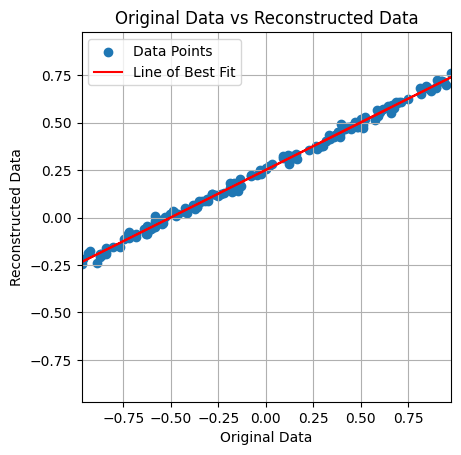

In [90]:
print("-----------------------------Analysis of Original vs Reconstructed----------------------------------")
avg_dif = 0
print("+----------------+----------------+----------------+")
print("| Original Data  | Reconstructed  | Difference     |")
print("+----------------+----------------+----------------+")

for o, r in zip(np.concatenate(all_data_list[0]).flatten(),
                np.concatenate(all_rec_list[0]).flatten()):
    dif = o - r
    avg_dif += dif
    print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

print("+----------------+----------------+----------------+")

n_points = len(np.concatenate(all_data_list[0]).flatten())
avg_dif /= n_points

print(f"Average Difference: {avg_dif}")


title = 'Original Data vs Reconstructed Data'
x_label = 'Original Data'
y_label = 'Reconstructed Data'
legend = 'Data Points'
plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                np.concatenate(all_data_list[0]).flatten(), 
                title, x_label, y_label, legend)

## Method 3
### Encode isovalue into the weight of the EHands addition

In [91]:
def test_qcrank_ehands_single_iso():
    n_arr = 1
    isovalue = 0.5
    weight = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=False)

        qc_main = QuantumCircuit(data_args['num_q'] + 1, data_args['num_q'] + 1)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        # Add EHands Addition
        q_a = data_args['data_qL'][0]
        q_b = q_a + 1

        qc_main = ehands_addition(qc_main, q_a, q_b, weight=weight, verbose=verbose, barrier=True)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

Addition Circuit:


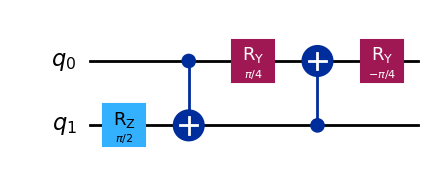

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=10
Gates count: OrderedDict({'ry': 10, 'cx': 10, 'measure': 4, 'h': 3, 'barrier': 2, 'rz': 1})


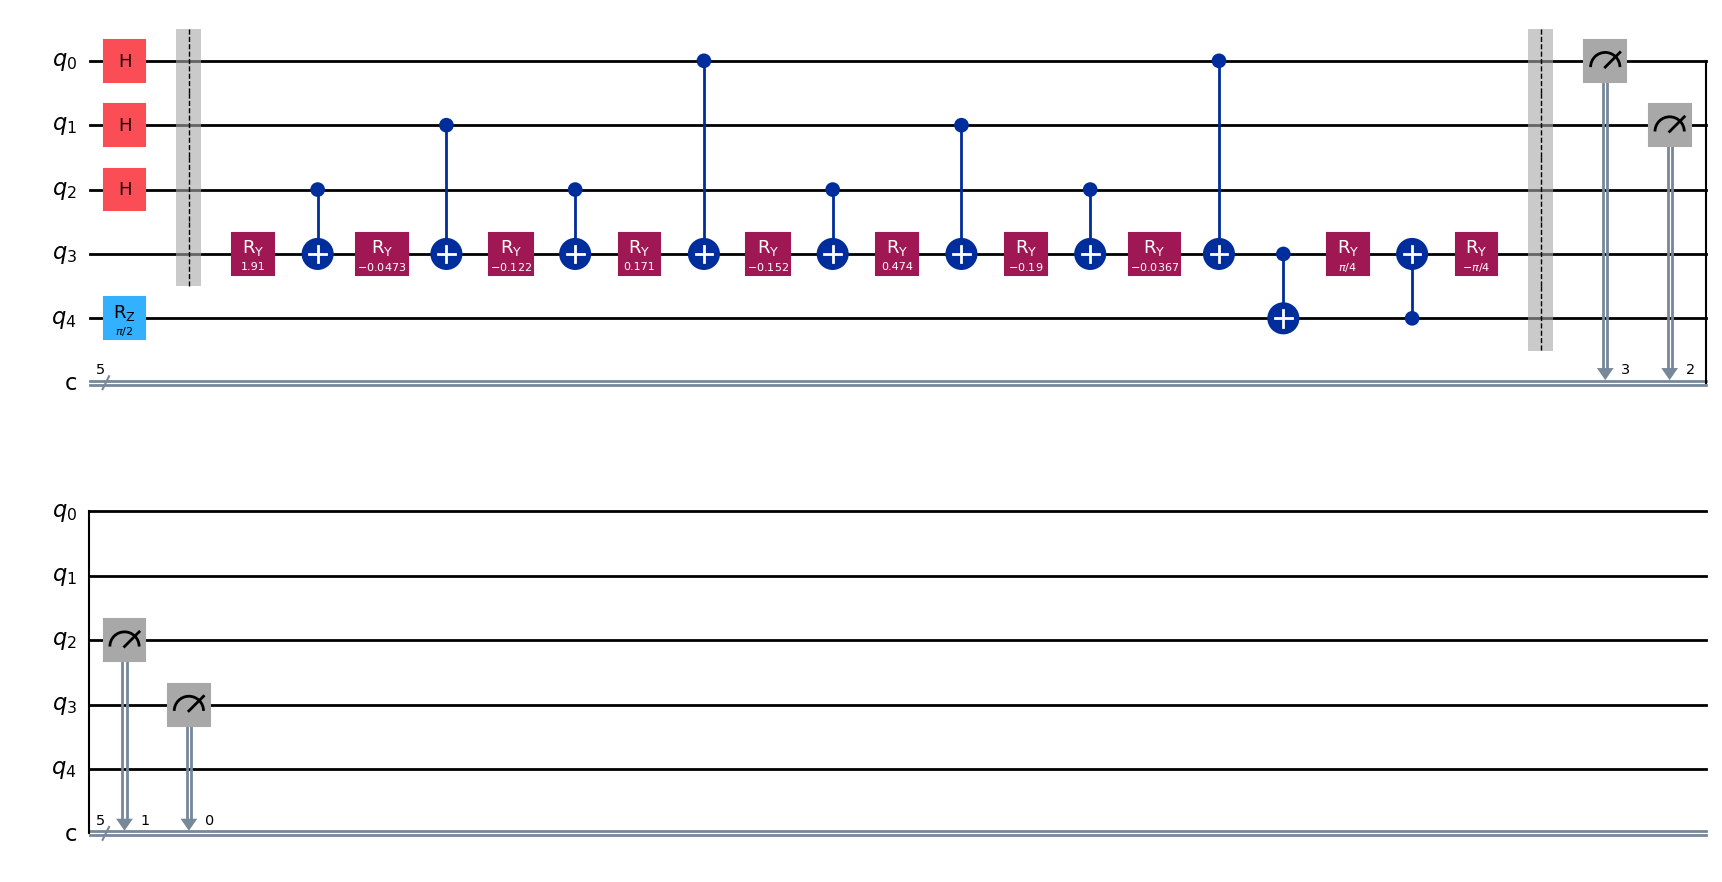

QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.645  std= 0.250  corr=1.00   tilt angle=2.4/deg
Overall 
residuals: mean=-0.645  std=0.250  corr=0.999


Cube 0 original data:
 [-0.42029531 -0.20435177  0.30281847 -0.76490936 -0.24090356 -0.91245681
 -0.7110377   0.63440862]
Reconstructed data:
 [0.28810274 0.40368098 0.65797244 0.13539074 0.38293217 0.02336904
 0.13820336 0.81097127]
Difference:
 [-0.70839805 -0.60803275 -0.35515397 -0.9003001  -0.62383573 -0.93582584
 -0.84924106 -0.17656264]
QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.541  std= 0.282  corr=1.00   tilt angle=1.6/deg
Overall 
residuals: mean=-0.541  std=0.282  corr=1.000

QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative erro

In [92]:
all_rec_list, all_data_list = test_qcrank_ehands_single_iso()

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.420295      | 0.288103       | -0.708398      |
| -0.204352      | 0.403681       | -0.608033      |
| 0.302818       | 0.657972       | -0.355154      |
| -0.764909      | 0.135391       | -0.900300      |
| -0.240904      | 0.382932       | -0.623836      |
| -0.912457      | 0.023369       | -0.935826      |
| -0.711038      | 0.138203       | -0.849241      |
| 0.634409       | 0.810971       | -0.176563      |
| -0.033880      | 0.474024       | -0.507904      |
| 0.218646       | 0.611084       | -0.392439      |
| 0.540531       | 0.762197       | -0.221665      |
| 0.517637       | 0.769138       | -0.251501      |
| 0.375318       | 0.674553       | -0.299235      |
| -0.632879      | 0.191880       | -0.824759      

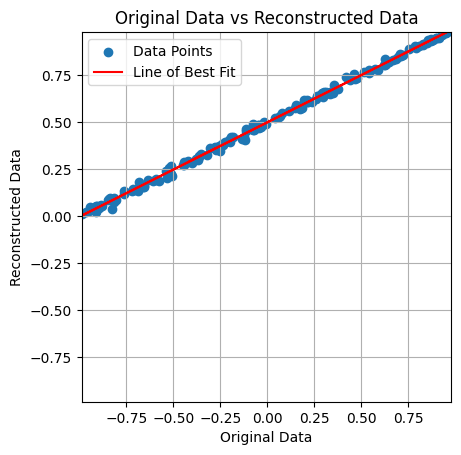

In [93]:
print("-----------------------------Analysis of Original vs Reconstructed----------------------------------")
avg_dif = 0
print("+----------------+----------------+----------------+")
print("| Original Data  | Reconstructed  | Difference     |")
print("+----------------+----------------+----------------+")

for o, r in zip(np.concatenate(all_data_list[0]).flatten(),
                np.concatenate(all_rec_list[0]).flatten()):
    dif = o - r
    avg_dif += dif
    print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

print("+----------------+----------------+----------------+")

n_points = len(np.concatenate(all_data_list[0]).flatten())
avg_dif /= n_points

print(f"Average Difference: {avg_dif}")


title = 'Original Data vs Reconstructed Data'
x_label = 'Original Data'
y_label = 'Reconstructed Data'
legend = 'Data Points'
plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                np.concatenate(all_data_list[0]).flatten(), 
                title, x_label, y_label, legend)